# RPS Territorial Walkers — Vertical Thirds

This notebook keeps the shared walker/space dynamics and changes only the territory/spawn setup to perturbed vertical thirds.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

EMPTY, ROCK, PAPER, SCISSORS = 0, 1, 2, 3
BASE_UPSET_CAPTURE_PROB = 0

STATE_COLORS = {
    EMPTY: "#f0f0f0",
    ROCK: "#000000",
    PAPER: "#0095DA",
    SCISSORS: "#86ff23"
}
STATE_NAMES = {
    EMPTY: "Empty",
    ROCK: "Rock",
    PAPER: "Paper",
    SCISSORS: "Scissors"
}

cmap = ListedColormap([STATE_COLORS[s] for s in [EMPTY, ROCK, PAPER, SCISSORS]])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

In [13]:
def winner(a, b):
    if a == b:
        return a
    if {a, b} == {ROCK, SCISSORS}:
        return ROCK
    if {a, b} == {SCISSORS, PAPER}:
        return SCISSORS
    if {a, b} == {PAPER, ROCK}:
        return PAPER
    raise ValueError(f"Invalid species pair: {a}, {b}")

def local_species_counts(walkers, n, m):
    counts = np.zeros((n, m, 4), dtype=np.int32)
    for w in walkers:
        counts[w["x"], w["y"], w["species"]] += 1
    return counts

def against_flow_capture_probability(attacker_count, defender_count, base_prob=BASE_UPSET_CAPTURE_PROB):
    advantage = max(0, int(attacker_count) - int(defender_count))
    return min(1.0, base_prob * advantage)

def step_system(grid, walkers, rng, periodic=True, flow_win_prob=0.9):
    n, m = grid.shape
    cell_counts = local_species_counts(walkers, n, m)
    moves = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)], dtype=np.int8)

    for i in rng.permutation(len(walkers)):
        w = walkers[i]
        x_old, y_old = w["x"], w["y"]
        species = int(w["species"])

        dx, dy = moves[rng.integers(0, 4)]
        x_new, y_new = x_old + int(dx), y_old + int(dy)

        if periodic:
            x_new %= n
            y_new %= m
        else:
            if not (0 <= x_new < n and 0 <= y_new < m):
                continue

        cell_counts[x_old, y_old, species] = max(0, cell_counts[x_old, y_old, species] - 1)

        destination = int(grid[x_new, y_new])
        final_species = species

        if destination == EMPTY:
            grid[x_new, y_new] = species
        elif destination != species:
            normal_winner = winner(species, destination)
            attacker_count = int(cell_counts[x_new, y_new, species]) + 1
            defender_count = int(cell_counts[x_new, y_new, destination])

            if normal_winner == species:
                conflict_winner = species if rng.random() < flow_win_prob else destination
            else:
                p_upset = against_flow_capture_probability(attacker_count, defender_count)
                conflict_winner = species if rng.random() < p_upset else destination

            grid[x_old, y_old] = conflict_winner
            grid[x_new, y_new] = conflict_winner
            final_species = int(conflict_winner)

        w["x"], w["y"], w["species"] = x_new, y_new, int(final_species)
        cell_counts[x_new, y_new, int(final_species)] += 1

def detect_borders(grid, periodic=True):
    n, m = grid.shape
    border_mask = np.zeros((n, m), dtype=bool)
    for x in range(n):
        for y in range(m):
            s = grid[x, y]
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                xn, yn = x + dx, y + dy
                if periodic:
                    xn %= n
                    yn %= m
                elif not (0 <= xn < n and 0 <= yn < m):
                    continue
                if grid[xn, yn] != s:
                    border_mask[x, y] = True
                    break
    return border_mask

def detect_takeover(grid):
    u = np.unique(grid)
    if len(u) == 1 and u[0] in (ROCK, PAPER, SCISSORS):
        return True, int(u[0])
    return False, None

def draw_color_key(ax_key):
    ax_key.axis("off")
    ax_key.set_title("Color key", fontsize=11)
    key_states = [ROCK, PAPER, SCISSORS, EMPTY]
    y0, dy = 0.82, 0.18
    for i, s in enumerate(key_states):
        y = y0 - i * dy
        ax_key.add_patch(
            plt.Rectangle(
                (0.08, y - 0.045),
                0.22,
                0.09,
                facecolor=STATE_COLORS[s],
                edgecolor="black",
                transform=ax_key.transAxes,
                clip_on=False,
            )
        )
        ax_key.text(
            0.36,
            y,
            f"{STATE_NAMES[s]} ({s})",
            transform=ax_key.transAxes,
            va="center",
            fontsize=10,
        )

def show_grid(grid, title="Grid"):
    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    ax.imshow(grid, cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)
    fig.tight_layout()
    plt.show()

In [14]:
# Scenario-specific setup: VERTICAL THIRDS (y-split with perturbed interfaces)
def setup_vertical_thirds(n=120, seed=0, periodic=True, border_spawn_prob=0.35, interface_perturb=2):
    rng = np.random.default_rng(seed)
    grid = np.zeros((n, n), dtype=np.int8)

    b1_base = n / 3.0
    b2_base = 2.0 * n / 3.0
    shifts = rng.integers(-interface_perturb, interface_perturb + 1, size=n)

    b1_by_x = np.zeros(n, dtype=np.int32)
    b2_by_x = np.zeros(n, dtype=np.int32)
    for x in range(n):
        b1 = int(np.clip(np.round(b1_base + shifts[x]), 1, n - 2))
        b2 = int(np.clip(np.round(b2_base + shifts[x]), b1 + 1, n - 1))
        b1_by_x[x] = b1
        b2_by_x[x] = b2

    for x in range(n):
        b1, b2 = b1_by_x[x], b2_by_x[x]
        for y in range(n):
            if y < b1:
                grid[x, y] = PAPER
            elif y < b2:
                grid[x, y] = ROCK
            else:
                grid[x, y] = SCISSORS

    border_mask = detect_borders(grid, periodic=periodic)

    walkers = []
    for x in range(n):
        for y in range(n):
            if border_mask[x, y] and rng.random() < border_spawn_prob:
                walkers.append({"x": x, "y": y, "species": int(grid[x, y])})

    for sp in [ROCK, PAPER, SCISSORS]:
        if not any(w["species"] == sp for w in walkers):
            candidates = np.argwhere((grid == sp) & border_mask)
            if len(candidates) > 0:
                idx = rng.integers(0, len(candidates))
                x0, y0 = candidates[idx]
                walkers.append({"x": int(x0), "y": int(y0), "species": int(sp)})

    return grid, walkers, rng

def run_vertical_thirds_trial(n=120, steps=1800, seed=21, periodic=True, frame_skip=30, border_spawn_prob=0.35, interface_perturb=2):
    grid, walkers, rng = setup_vertical_thirds(
        n=n, seed=seed, periodic=periodic, border_spawn_prob=border_spawn_prob, interface_perturb=interface_perturb
    )
    frames = [grid.copy()]
    takeover_step, winner_species = None, None

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=periodic, flow_win_prob=0.9)
        if (t % frame_skip) == 0:
            frames.append(grid.copy())
        done, ws = detect_takeover(grid)
        if done:
            takeover_step, winner_species = t, ws
            if (t % frame_skip) != 0:
                frames.append(grid.copy())
            break

    return {
        "grid": grid,
        "walkers": walkers,
        "frames": frames,
        "takeover_step": takeover_step,
        "winner_species": winner_species
    }

### JC: I know this isnt optimal for the class but to save space and also because I legitamitely forgot, I reiterated the next 2 cells over and over again to see the limitations of the code, and what conditions display different scenarios. But I have found that the larger the number of, n, the longer period of stability the model goes under this symmetry.

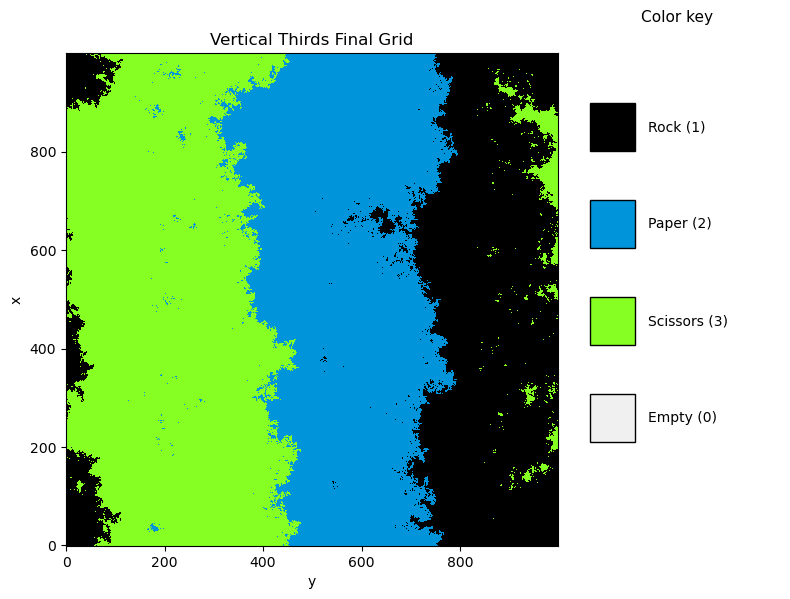

{'takeover_step': None, 'winner': None, 'num_walkers': 8605, 'num_saved_frames': 61}


In [17]:
result = run_vertical_thirds_trial(
    n=1000, steps=18000, seed=np.random.seed(), periodic=True, frame_skip=300, border_spawn_prob=0.99, interface_perturb=2
)
show_grid(result["grid"], title="Vertical Thirds Final Grid")
print({
    "takeover_step": result["takeover_step"],
    "winner": None if result["winner_species"] is None else STATE_NAMES[result["winner_species"]],
    "num_walkers": len(result["walkers"]),
    "num_saved_frames": len(result["frames"])
})

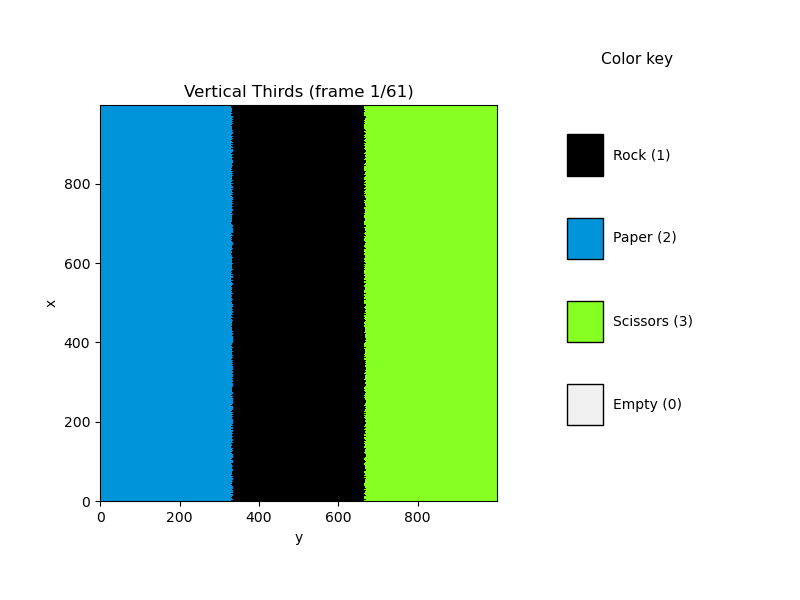

Saved GIF: /Users/joshuaclavecillas/anaconda_projects/Computational_folder/vertical_thirds.gif
Rendered embedded HTML animation.


In [18]:
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Image, display


def render_frames_gif_and_html(frames, gif_name="vertical_thirds.gif", fps=12):
    if not frames:
        raise ValueError("No frames available to animate.")

    gif_path = Path.cwd() / gif_name

    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    im = ax.imshow(frames[0], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)

    def update(i):
        im.set_data(frames[i])
        ax.set_title(f"Vertical Thirds (frame {i+1}/{len(frames)})")
        return [im]

    ani = FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps, blit=False)

    ani.save(gif_path, writer=PillowWriter(fps=fps))
    html_anim = ani.to_jshtml(fps=fps)
    plt.close(fig)

    display(HTML(html_anim))
    display(Image(filename=str(gif_path)))

    print(f"Saved GIF: {gif_path}")
    print("Rendered embedded HTML animation.")


render_frames_gif_and_html(result["frames"], gif_name="vertical_thirds.gif", fps=12)

### JC: It would be easier to display all on one png the difference between a large grid and smaller grid.

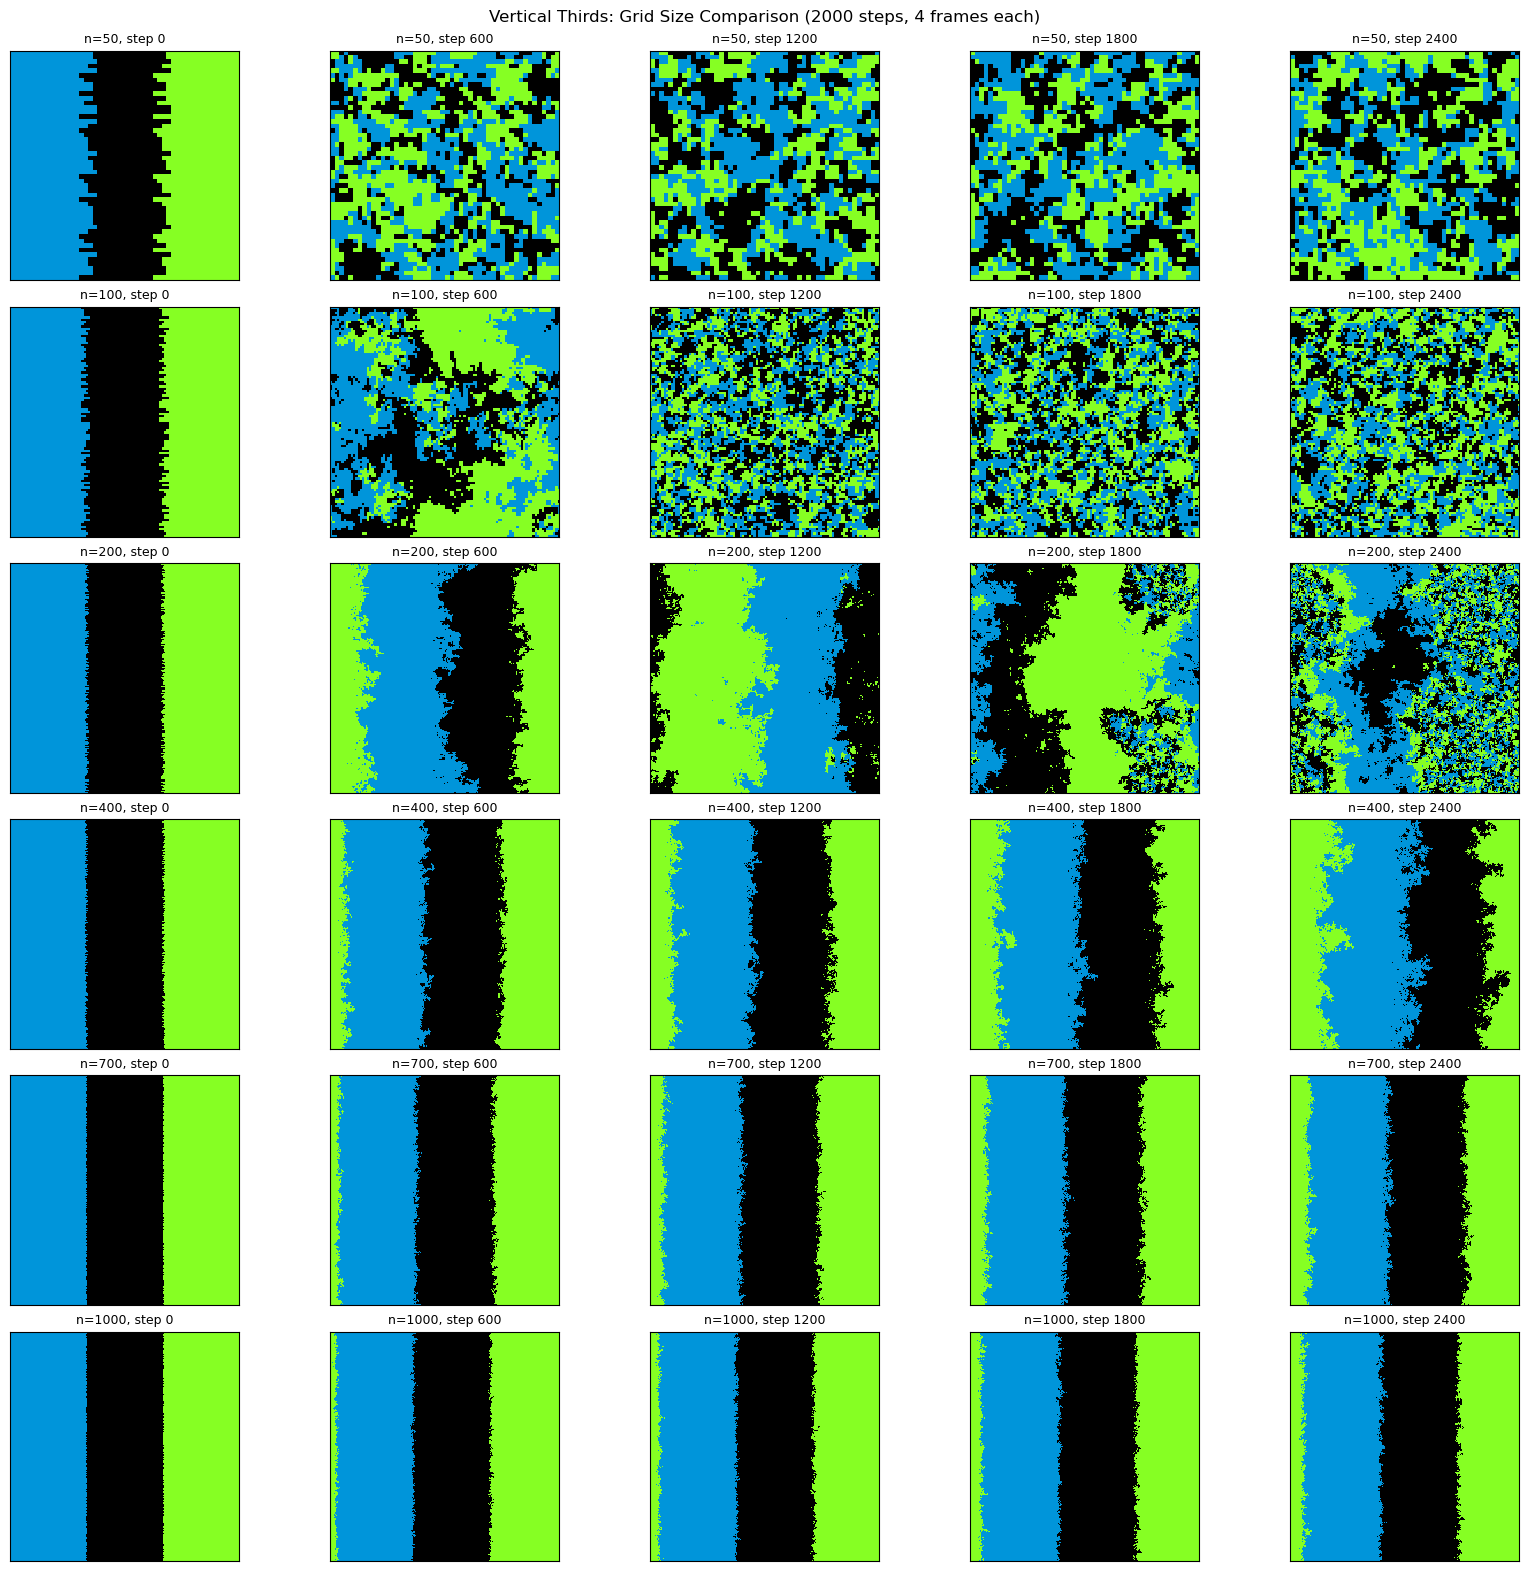

Saved comparison PNG: /Users/joshuaclavecillas/anaconda_projects/Computational_folder/vertical_thirds_grid_size_comparison.png


In [9]:
from pathlib import Path

# Compare grid sizes on one PNG: each trial runs 2000 steps and shows 4 sampled frames.
grid_sizes = [50, 100, 200, 400, 700, 1000]
steps = 2400
frames_per_trial = 5
seed_base = 42

def run_vertical_thirds_trial_with_steps(
    n=120,
    steps=2000,
    seed=21,
    periodic=True,
    frame_skip=200,
    border_spawn_prob=0.99,
    interface_perturb=2,
    flow_win_prob=0.9,
 ):
    grid, walkers, rng = setup_vertical_thirds(
        n=n,
        seed=seed,
        periodic=periodic,
        border_spawn_prob=border_spawn_prob,
        interface_perturb=interface_perturb,
    )
    frames = [grid.copy()]
    frame_steps = [0]
    takeover_step, winner_species = None, None

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=periodic, flow_win_prob=flow_win_prob)
        if (t % frame_skip) == 0:
            frames.append(grid.copy())
            frame_steps.append(t)

        done, ws = detect_takeover(grid)
        if done:
            takeover_step, winner_species = t, ws
            if (t % frame_skip) != 0:
                frames.append(grid.copy())
                frame_steps.append(t)
            break

    return {
        "frames": frames,
        "frame_steps": frame_steps,
        "takeover_step": takeover_step,
        "winner_species": winner_species,
    }

# Build figure: rows = grid sizes, cols = sampled frames
fig, axes = plt.subplots(
    len(grid_sizes),
    frames_per_trial,
    figsize=(3.2 * frames_per_trial, 2.6 * len(grid_sizes)),
    constrained_layout=True,
    squeeze=False,
 )

for row, n in enumerate(grid_sizes):
    frame_skip = max(1, steps // (frames_per_trial - 1))
    trial = run_vertical_thirds_trial_with_steps(
        n=n,
        steps=steps,
        seed=seed_base + row,
        periodic=True,
        frame_skip=frame_skip,
        border_spawn_prob=0.99,
        interface_perturb=2,
        flow_win_prob=0.9,
    )

    frames = trial["frames"]
    frame_steps = trial["frame_steps"]

    sample_idx = np.linspace(0, len(frames) - 1, frames_per_trial).round().astype(int)
    sample_idx = np.clip(sample_idx, 0, len(frames) - 1)

    for col, idx in enumerate(sample_idx):
        ax = axes[row, col]
        ax.imshow(frames[idx], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
        step_label = frame_steps[idx]
        ax.set_title(f"n={n}, step {step_label}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

png_path = Path.cwd() / "vertical_thirds_grid_size_comparison.png"
fig.suptitle("Vertical Thirds: Grid Size Comparison (2000 steps, 4 frames each)", fontsize=12)
fig.savefig(png_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved comparison PNG: {png_path}")